Homework Project 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import cv2

Part 1: Fun with Filters

Part 1.1：  Convolutions from Scratch

conv 4-for loops

In [4]:
def conv2d_four_loops(img, kernel):
    I = np.asarray(img, dtype=np.float32)
    K = np.asarray(kernel, dtype=np.float32)
    H, W = I.shape; kh, kw = K.shape
    pad_h, pad_w = kh//2, kw//2
    P = np.pad(I, ((pad_h,pad_h),(pad_w,pad_w)), mode='constant')
    
    out = np.zeros((H, W), dtype=np.float32)
    for i in range(H):
        for j in range(W):
            acc = 0.0
            for m in range(kh):
                for n in range(kw):
                    val = P[i+m, j+n]
                    w = K[kh-1-m, kw-1-n]  # the flip
                    acc += val * w
            out[i, j] = acc
    return out

conv 2 for-loops

In [5]:
def conv2d_two_loops(img, kernel):
    I  = np.asarray(img, dtype=np.float32)
    K  = np.asarray(kernel, dtype=np.float32)
    H, W     = I.shape
    kh, kw   = K.shape
    pad_h    = kh // 2
    pad_w    = kw // 2
    P = np.pad(I, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')

    Kf = K[::-1, ::-1]

    out = np.empty((H, W), dtype=np.float32)
    for i in range(H):
        for j in range(W):
            win = P[i:i+kh, j:j+kw]
            out[i, j] = np.sum(win * Kf)
    return out

compare woth scipy

In [ ]:
from scipy.signal import convolve2d

I = np.arange(25, dtype=np.float32).reshape(5,5)
K = np.array([[0, 1, 0],
              [1,-4, 1],
              [0, 1, 0]], dtype=np.float32)

out4  = conv2d_four_loops(I, K)  
out2  = conv2d_two_loops(I, K) 
ref   = convolve2d(I, K, mode='same', boundary='fill', fillvalue=0)

print("4-loop vs SciPy  allclose:", np.allclose(out4, ref), " max diff:", np.max(np.abs(out4-ref)))
print("2-loop vs SciPy  allclose:", np.allclose(out2, ref), " max diff:", np.max(np.abs(out2-ref)))
print("4-loop vs 2-loop allclose:", np.allclose(out4, out2), " max diff:", np.max(np.abs(out4-out2)))

4-loop vs SciPy  allclose: True  max diff: 0.0
2-loop vs SciPy  allclose: True  max diff: 0.0
4-loop vs 2-loop allclose: True  max diff: 0.0


True

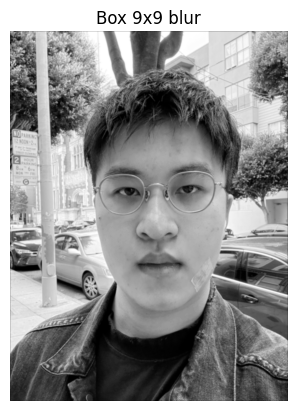

In [7]:
import cv2, numpy as np
import matplotlib.pyplot as plt

Iu8  = cv2.imread("pictures/1-1.jpg", cv2.IMREAD_GRAYSCALE)
I    = Iu8.astype(np.float32) / 255.0

# 1) Create a kernel
K_box = np.ones((9,9), dtype=np.float32) / 81.0

# 2) Convolve (your two-loop function)
I_blur = conv2d_two_loops(I, K_box)

# 3) Clip and display/save
I_blur = np.clip(I_blur, 0.0, 1.0)
plt.figure(); plt.imshow(I_blur, cmap="gray"); plt.axis("off"); plt.title("Box 9x9 blur")
cv2.imwrite("1-1blur.png", (I_blur*255).astype(np.uint8))

True

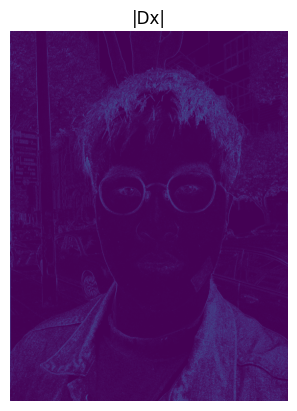

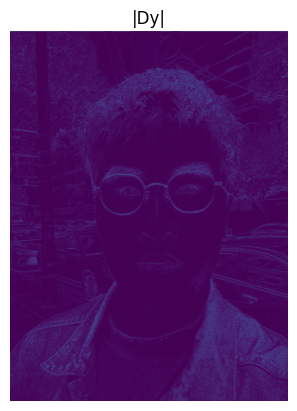

In [ ]:
Dx = np.array([[1, -1]], dtype=np.float32) 
Dy = Dx.T 

Ix = conv2d_two_loops(I, Dx)
Iy = conv2d_two_loops(I, Dy)

Ix_vis = np.clip(np.abs(Ix), 0, 1)
Iy_vis = np.clip(np.abs(Iy), 0, 1)

plt.figure(); plt.imshow(Ix_vis); plt.axis("off"); plt.title("|Dx|")
plt.figure(); plt.imshow(Iy_vis); plt.axis("off"); plt.title("|Dy|")

cv2.imwrite("1-1dx.png", (Ix_vis*255).astype(np.uint8))
cv2.imwrite("1-1dy.png", (Iy_vis*255).astype(np.uint8))

Part 1.2: Finite Difference Operator

In [137]:
import cv2, numpy as np
from scipy.signal import convolve2d

Iu8 = cv2.imread("pictures/cameraman.png", cv2.IMREAD_GRAYSCALE)
I   = Iu8.astype(np.float32) / 255.0

Dx = np.array([[1, -1]], dtype=np.float32)  # horizontal derivative (right - left)
Dy = Dx.T  

Gx = convolve2d(I, Dx, mode='same', boundary='fill', fillvalue=0)
Gy = convolve2d(I, Dy, mode='same', boundary='fill', fillvalue=0)

mag = np.sqrt(Gx**2 + Gy**2)
mag /= (mag.max())

tau = 0.174
edges = (mag >= tau).astype(np.uint8) * 255

libpng warning: iCCP: profile 'icc': 0h: PCS illuminant is not D50


True

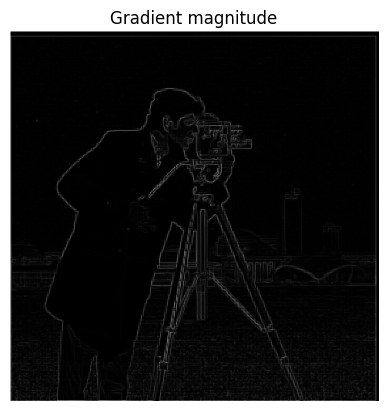

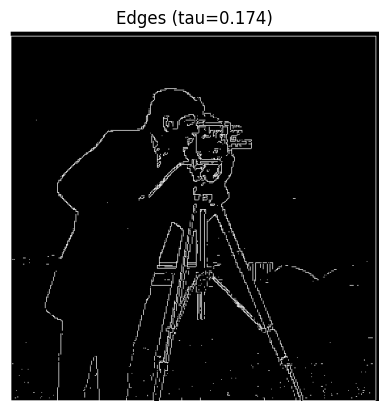

In [138]:
import matplotlib.pyplot as plt
plt.figure(); plt.imshow(mag, cmap="gray"); plt.axis("off"); plt.title("Gradient magnitude")
plt.figure(); plt.imshow(edges, cmap="gray"); plt.axis("off"); plt.title(f"Edges (tau={tau})")
cv2.imwrite("cameraman-edge.png", (edges).astype(np.uint8))
cv2.imwrite("cameraman-gm.png", (mag).astype(np.uint8))

Part 1.3: Derivative of Gaussian (DoG) Filter

In [148]:
import numpy as np, cv2
from scipy.signal import convolve2d

g1 = cv2.getGaussianKernel(11, 1)
G2 = g1 @ g1.T
G2 = g1 @ g1.T 

Dx = np.array([[1, -1]], dtype=np.float32)
Dy = Dx.T

I_blur = convolve2d(I, G2, mode='same', boundary='fill', fillvalue=0)
Gx_A   = convolve2d(I_blur, Dx, mode='same', boundary='fill', fillvalue=0)
Gy_A   = convolve2d(I_blur, Dy, mode='same', boundary='fill', fillvalue=0)

mag_A = np.sqrt(Gx_A**2 + Gy_A**2)
mag_A /= (mag_A.max())
tau = 0.05
edges = (mag_A >= tau).astype(np.uint8) * 255 

True

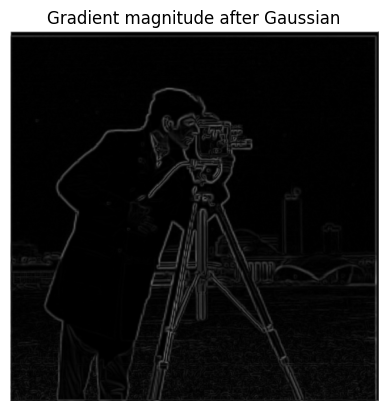

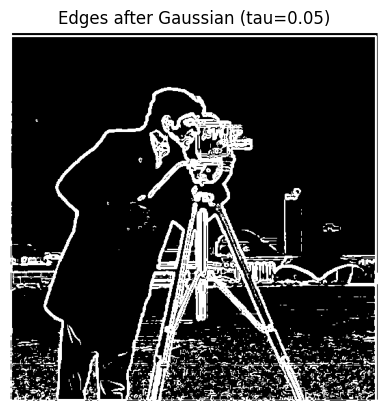

In [149]:
import matplotlib.pyplot as plt
plt.figure(); plt.imshow(mag_A, cmap="gray"); plt.axis("off"); plt.title("Gradient magnitude after Gaussian")
plt.figure(); plt.imshow(edges, cmap="gray"); plt.axis("off"); plt.title(f"Edges after Gaussian (tau={tau})")
cv2.imwrite("cameraman-edge-gaussian.png", (edges).astype(np.uint8))
cv2.imwrite("cameraman-gm-gaussian.png", (mag_A).astype(np.uint8))

What difference I see: the edge picture affter applying the Gaussian filter become less noisy

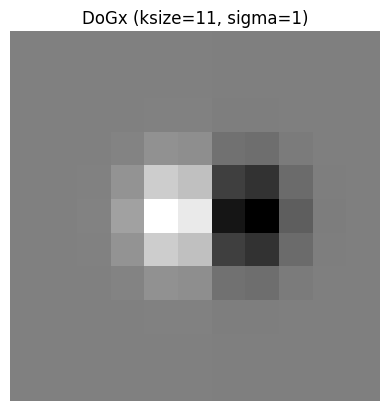

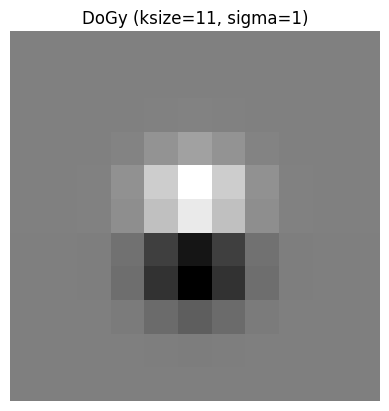

True

In [141]:
DoGx = convolve2d(G2, Dx, mode='same', boundary='fill', fillvalue=0)
DoGy = convolve2d(G2, Dy, mode='same', boundary='fill', fillvalue=0)

DoGx_v = DoGx / np.max(np.abs(DoGx))
DoGy_v = DoGy / np.max(np.abs(DoGy))

plt.figure()
plt.imshow(DoGx_v, cmap='gray', vmin=-1, vmax=1)
plt.title(f"DoGx (ksize=11, sigma=1)")
plt.axis('off')

plt.figure()
plt.imshow(DoGy_v, cmap='gray', vmin=-1, vmax=1)
plt.title(f"DoGy (ksize=11, sigma=1)")
plt.axis('off')

plt.show()

cv2.imwrite("DoGx_ksize11_sigma1.png", (DoGx_v * 255).astype(np.uint8))
cv2.imwrite("DoGy_ksize11_sigma1.png", (DoGy_v * 255).astype(np.uint8))

True

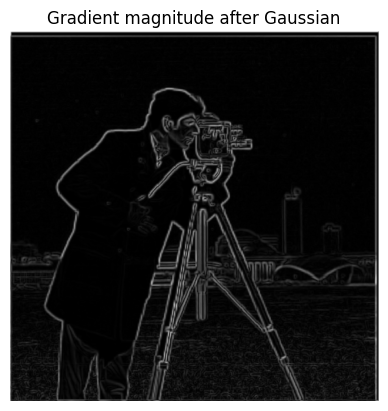

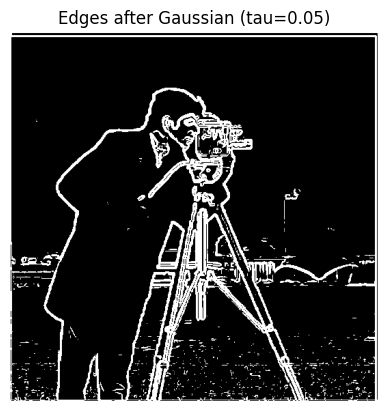

In [151]:
import matplotlib.pyplot as plt
plt.figure(); plt.imshow(mag_B, cmap="gray"); plt.axis("off"); plt.title("Gradient magnitude after Gaussian")
plt.figure(); plt.imshow(edges, cmap="gray"); plt.axis("off"); plt.title(f"Edges after Gaussian (tau={tau})")
cv2.imwrite("cameraman-edge-gaussian.png", (edges).astype(np.uint8))
cv2.imwrite("cameraman-gm-gaussian.png", (mag_B).astype(np.uint8))

Verify that you get the same result as before: Yes both looks exactly the same

Part 2: Fun with Frequencies!

Part 2.1: Image "Sharpening"

In [153]:
import numpy as np, cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

def gaussian_kernel(ksize=11, sigma=2):
    ax = np.arange(-(ksize//2), ksize//2 + 1)
    dx, dy = np.meshgrid(ax, ax)
    kernel = np.exp(-(dx**2 + dy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel

def unsharp_mask(I, ksize=11, sigma=2.0, alpha=1.5):
    g = gaussian_kernel(ksize, sigma)
    low  = convolve2d(I, g, mode='same', boundary='symm')
    high = I - low
    sharp = np.clip(I + alpha * high, 0.0, 1.0)
    return low, high, sharp


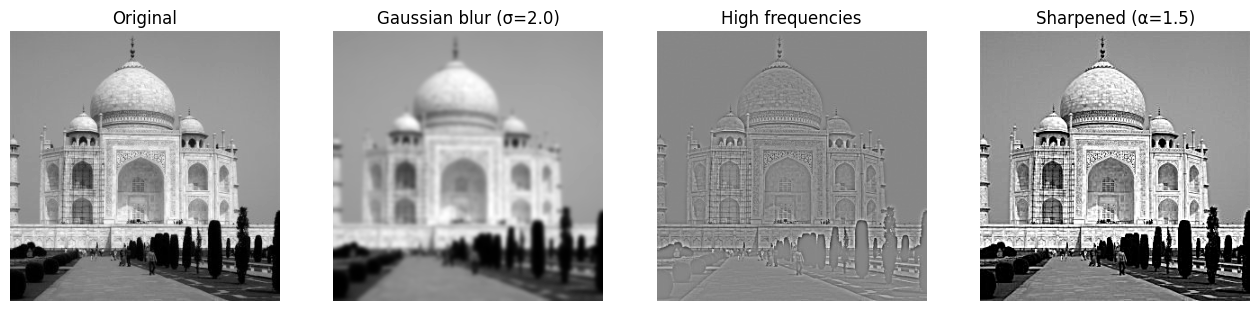

In [154]:
# Taj (grayscale)
img_path = 'pictures/taj.jpg'
Iu8 = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
I = Iu8.astype(np.float32)/255.0

ksize, sigma, alpha = 11, 2.0, 1.5
low, high, sharp = unsharp_mask(I, ksize=ksize, sigma=sigma, alpha=alpha)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(I, cmap='gray'); axs[0].set_title('Original'); axs[0].axis('off')
axs[1].imshow(low, cmap='gray'); axs[1].axis('off')
hp_disp = (high - high.min()) / (high.max() - high.min() + 1e-8)
axs[2].imshow(hp_disp, cmap='gray'); axs[2].axis('off')
axs[3].imshow(sharp, cmap='gray'); axs[3].axis('off')
plt.show()


images of my choice

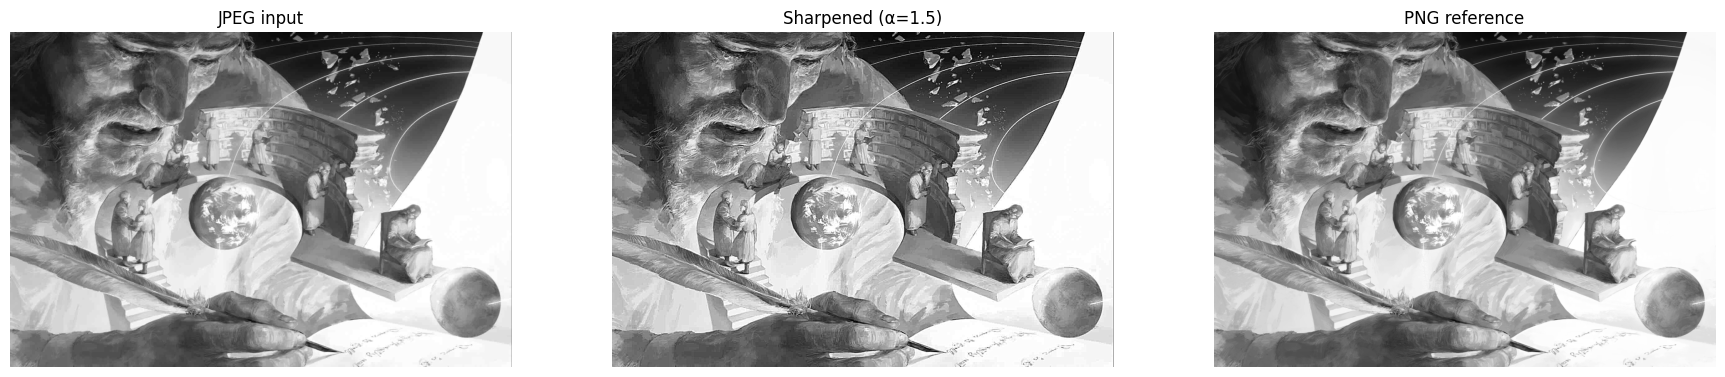

In [ ]:
jpg_path = 'pictures/blury.jpg'
png_path = 'pictures/original.PNG'
J_u8 = cv2.imread(jpg_path, cv2.IMREAD_GRAYSCALE)
P_u8 = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
J = J_u8.astype(np.float32)/255.0
P = P_u8.astype(np.float32)/255.0
low_J, high_J, sharp_J = unsharp_mask(J, ksize=ksize, sigma=sigma, alpha=alpha)

H = min(P.shape[0], sharp_J.shape[0])
W = min(P.shape[1], sharp_J.shape[1])
P_c = P[:H, :W]
J_c = J[:H, :W]
S_c = sharp_J[:H, :W]

mse = np.mean((S_c - P_c)**2)
psnr = 10.0 * np.log10(1.0 / (mse + 1e-12))

fig, axs = plt.subplots(1, 3, figsize=(22, 5))
axs[0].imshow(J_c, cmap='gray'); axs[0].axis('off')
axs[1].imshow(S_c, cmap='gray'); axs[1].axis('off')
axs[2].imshow(P_c, cmap='gray'); axs[2].axis('off')
plt.show()


Part 2.2: Hybrid Images

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

def read_gray(path):
    Iu8 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if Iu8 is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    return Iu8.astype(np.float32) / 255.0

def shift_image(img, dx=0, dy=0):
    H, W = img.shape[:2]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(img, M, (W, H),
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REFLECT)

def gaussian_kernel(ksize=11, sigma=2.0):
    ax = np.arange(-(ksize//2), ksize//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    k /= k.sum()
    return k

def apply_gaussian(I, ksize=11, sigma=2.0, boundary='symm'):
    g = gaussian_kernel(ksize, sigma)
    return convolve2d(I, g, mode='same',
                      boundary=boundary,
                      fillvalue=0)

def high_pass(I, ksize=11, sigma=2.0, boundary='symm'):
    low = apply_gaussian(I, ksize, sigma, boundary=boundary)
    return I - low

def make_hybrid(A, B,
                sigma_low=8.0, sigma_high=3.0,
                k_low=None, k_high=None,
                wA=1.0, wB=1.0,
                boundary='symm'):

    if k_low is None:  k_low  = (int(6*sigma_low + 1) | 1)
    if k_high is None: k_high = (int(6*sigma_high + 1) | 1)

    A_low  = apply_gaussian(A, k_low,  sigma_low,  boundary=boundary)
    B_high = high_pass(B,    k_high, sigma_high, boundary=boundary)
    H = np.clip(wA*A_low + wB*B_high, 0.0, 1.0)
    return A_low, B_high, H


def fft_log_mag(I):
    F = np.fft.fftshift(np.fft.fft2(I))
    mag = np.log1p(np.abs(F))
    mag = (mag - mag.min()) / (mag.max() - mag.min())
    return mag

def show_row(imgs, titles=None, figsize=(18,4)):
    n = len(imgs)
    plt.figure(figsize=figsize)
    for i, im in enumerate(imgs):
        plt.subplot(1, n, i+1)
        plt.imshow(np.clip(im, 0, 1), cmap='gray')
        if titles: plt.title(titles[i])
        plt.axis('off')
    plt.show()

def stretch_xy(img, sx=1.0, sy=1.0, interpolation=cv2.INTER_LINEAR):
    H, W = img.shape[:2]
    newW = int(round(W * sx))
    newH = int(round(H * sy))
    return cv2.resize(img, (newW, newH), interpolation=interpolation)


def pad_to_ref(img, ref, dx=0, dy=0, fill=0.0):
    H, W = ref.shape[:2]
    canvas = np.full((H, W), fill, dtype=img.dtype)
    ih, iw = img.shape[:2]
    x0, y0 = int(dx), int(dy)
    x1 = max(0, x0)
    y1 = max(0, y0)
    x2 = min(W, x0 + iw)
    y2 = min(H, y0 + ih)
    sx1 = max(0, -x0)
    sy1 = max(0, -y0)
    sx2 = sx1 + (x2 - x1)
    sy2 = sy1 + (y2 - y1)
    canvas[y1:y2, x1:x2] = img[sy1:sy2, sx1:sx2]
    return canvas

Picture 1

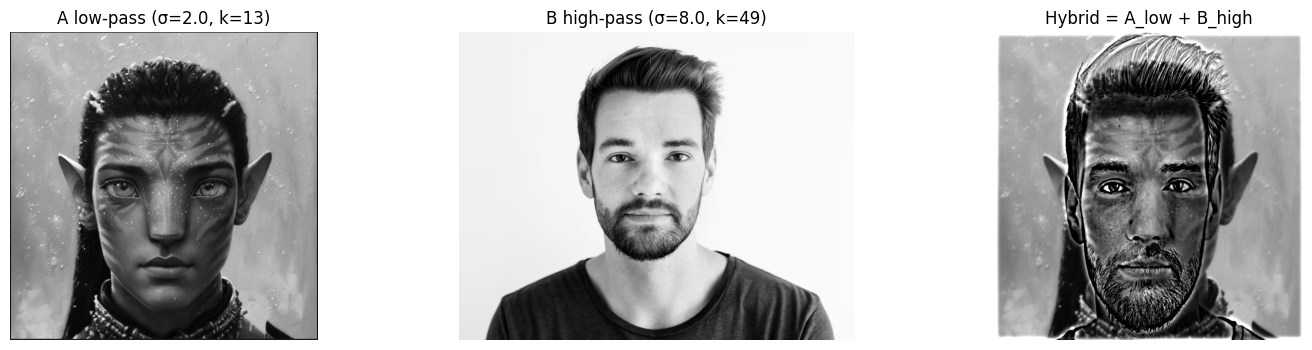

In [ ]:
A_path = 'pictures/face2.png'
B_path = 'pictures/face1.jpg'

A0 = read_gray(A_path) 
B0 = read_gray(B_path)

sx, sy = 2, 2.5
B_stretch = stretch_xy(B0, sx=sx, sy=sy, interpolation=cv2.INTER_CUBIC)

dx, dy = -208, -70
B_on_A = pad_to_ref(B_stretch, A0, dx=dx, dy=dy, fill=0.0)

overlay = np.clip(0.5*A0 + 0.5*B_on_A, 0.0, 1.0)

sigma_low  = 2.0   # A 
sigma_high = 8.0   # B 
k_low  = (int(6*sigma_low  + 1) | 1)
k_high = (int(6*sigma_high + 1) | 1)

A_low  = apply_gaussian(A0,k_low,  sigma_low,boundary='fill')
B_high = high_pass(B_on_A, k_high, sigma_high, boundary='fill')

wA, wB = 1.0, 3.0
H = np.clip(wA*A_low + wB*B_high, 0.0, 1.0)

show_row([A0, B0, H])

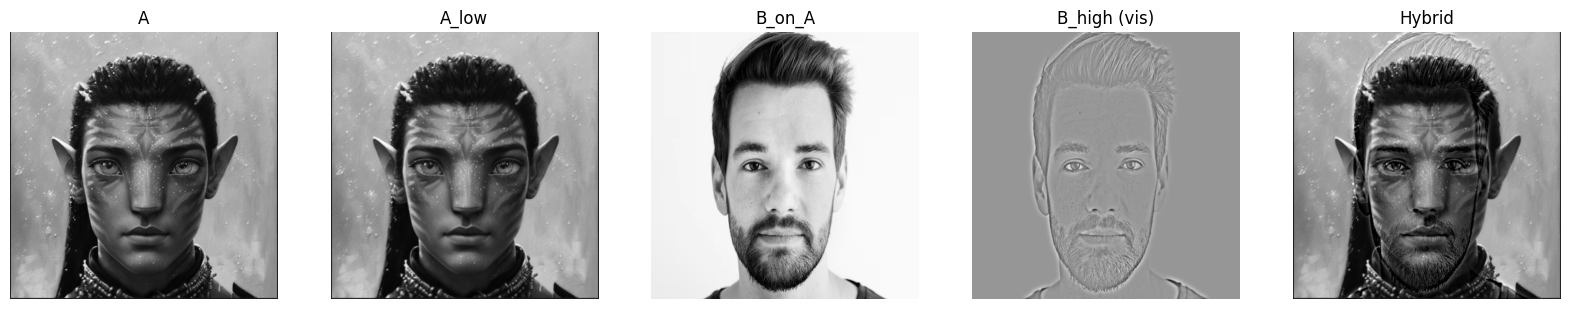

In [118]:
sigma_low, sigma_high =  1.0, 8.5
A_low, B_high, H = make_hybrid(A0, B_on_A, sigma_low=sigma_low, sigma_high=sigma_high, wA=1.0, wB=1.0)
B_high_vis = (B_high - B_high.min())/(B_high.max()-B_high.min()+1e-8)
show_row([A0, A_low, B_on_A, B_high_vis, H], figsize=(20,4))


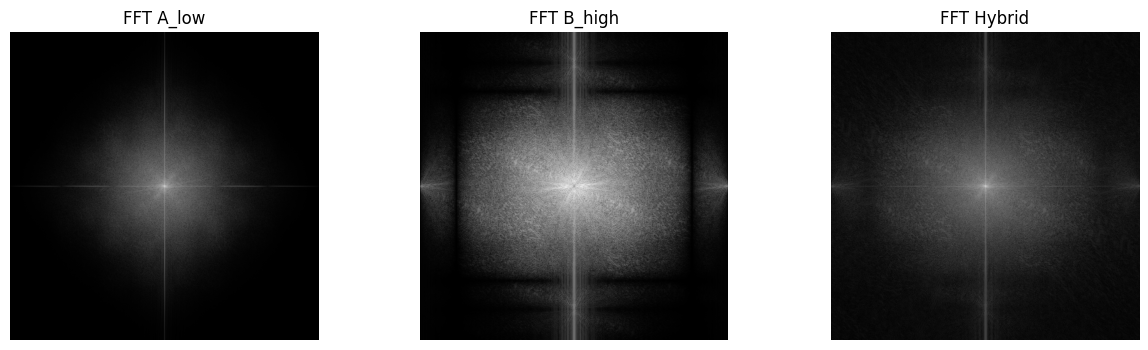

In [119]:
show_row([fft_log_mag(A_low), fft_log_mag(B_high), fft_log_mag(H)], figsize=(15,4))


Failure

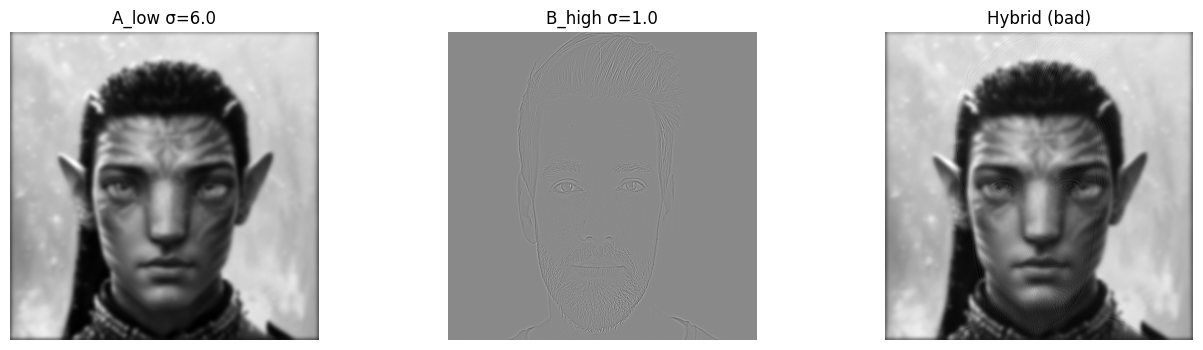

In [120]:
bad_sigma_low, bad_sigma_high = 6.0, 1.0
A_low_bad, B_high_bad, H_bad = make_hybrid(A0, B_on_A, sigma_low=bad_sigma_low, sigma_high=bad_sigma_high, wA=1.0, wB=1.0)
B_high_bad_vis = (B_high_bad - B_high_bad.min())/(B_high_bad.max()-B_high_bad.min()+1e-8)
show_row([A_low_bad, B_high_bad_vis, H_bad], [f'A_low σ={bad_sigma_low}', f'B_high σ={bad_sigma_high}', 'Hybrid (bad)'], figsize=(16,4))

Picture 2

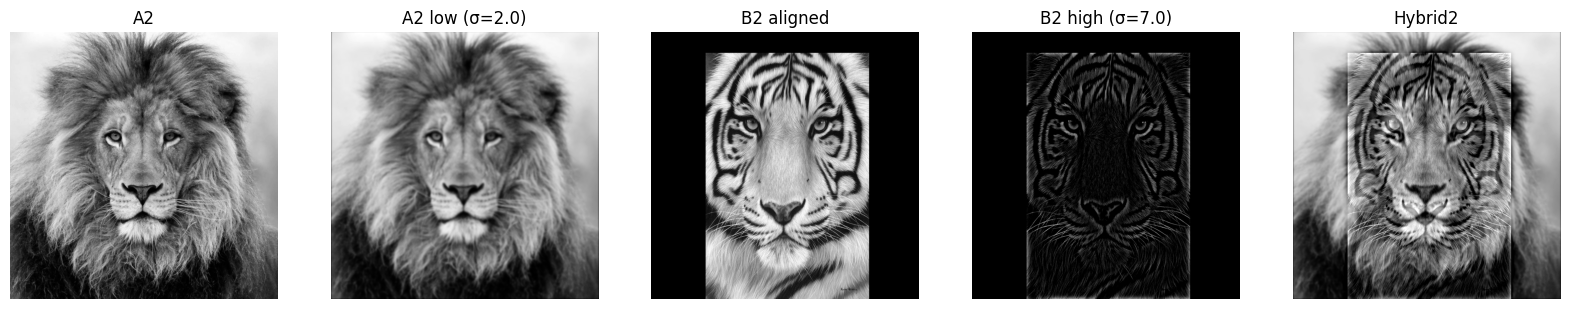

In [139]:
A2_path = 'pictures/lion.jpg'
B2_path = 'pictures/tiger.jpg'
A2 = read_gray(A2_path)
B2 = read_gray(B2_path)


sx2, sy2 = 0.8, 1.00
B2_stretch = stretch_xy(B2, sx=sx2, sy=sy2, interpolation=cv2.INTER_CUBIC)

dx2, dy2 = 150, 60
B2_on_A2 = pad_to_ref(B2_stretch, A2, dx=dx2, dy=dy2, fill=0.0)

sigma_low2, sigma_high2 = 2.0, 7.0
A2_low, B2_high, H2 = make_hybrid(A2, B2_on_A2,
                                  sigma_low=sigma_low2, sigma_high=sigma_high2,
                                  wA=1.0, wB=1.0, boundary='fill')


show_row([A2, A2_low, B2_on_A2, B2_high, H2], figsize=(20,4))


Part 2.3

In [ ]:
def read_rgb01(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb.astype(np.float32) / 255.0

def save_rgb01(path, I):
    I = np.clip(I, 0, 1)
    bgr = cv2.cvtColor((I*255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    cv2.imwrite(path, bgr)


def apply_gaussian_rgb(I, ksize=11, sigma=2.0, boundary='fill'):
    if I.ndim == 2:
        return cv2.GaussianBlur(I, (ksize, ksize), sigmaX=sigma)
    out = np.empty_like(I)
    for c in range(I.shape[2]):
        out[..., c] = cv2.GaussianBlur(I[..., c], (ksize, ksize), sigmaX=sigma)
    return out


def gaussian_stack(I, levels=6, sigma=2.0, boundary='fill'):
    ksize = (int(6*sigma + 1) | 1)
    G = [I]
    for _ in range(1, levels):
        G.append(apply_gaussian_rgb(G[-1], ksize, sigma))
    return G

def laplacian_stack(G):
    L = [G[i] - G[i+1] for i in range(len(G)-1)]
    G_top = G[-1]
    return L, G_top

def reconstruct_from_laplacian(L, top):
    rec = top.copy()
    for Li in reversed(L):
        rec = rec + Li
    return rec

def make_step_mask(H, W, orientation='vertical', split=0.5):
    M = np.zeros((H, W), dtype=np.float32)
    if orientation == 'vertical':
        col = int(W*split); M[:, :col] = 1.0
    else:
        row = int(H*split); M[:row, :] = 1.0
    return M

def gaussian_stack_mask(M, levels=6, sigma=2.0, boundary='fill'):
    return gaussian_stack(M, levels, sigma, boundary)


def multires_blend_rgb(A, B, M, levels=6, sigma=2.0, boundary='fill'):
    GA = gaussian_stack(A, levels, sigma)
    GB = gaussian_stack(B, levels, sigma)
    LA, A_top = laplacian_stack(GA)
    LB, B_top = laplacian_stack(GB)
    GM = gaussian_stack_mask(M, levels, sigma)

    LO = [GM[i][..., None]*LA[i] + (1.0 - GM[i])[..., None]*LB[i] for i in range(levels-1)]
    O_top = GM[-1][..., None]*A_top + (1.0 - GM[-1])[..., None]*B_top

    O = reconstruct_from_laplacian(LO, O_top)
    return np.clip(O, 0, 1), (GA, GB, GM, LA, LB, LO, O_top)


def vis01(x):
    xmin, xmax = x.min(), x.max()
    if xmax - xmin < 1e-8:
        return np.zeros_like(x) if x.ndim==2 else np.zeros_like(x) + 0.5
    return (x - xmin) / (xmax - xmin + 1e-8)


apply to the oraple

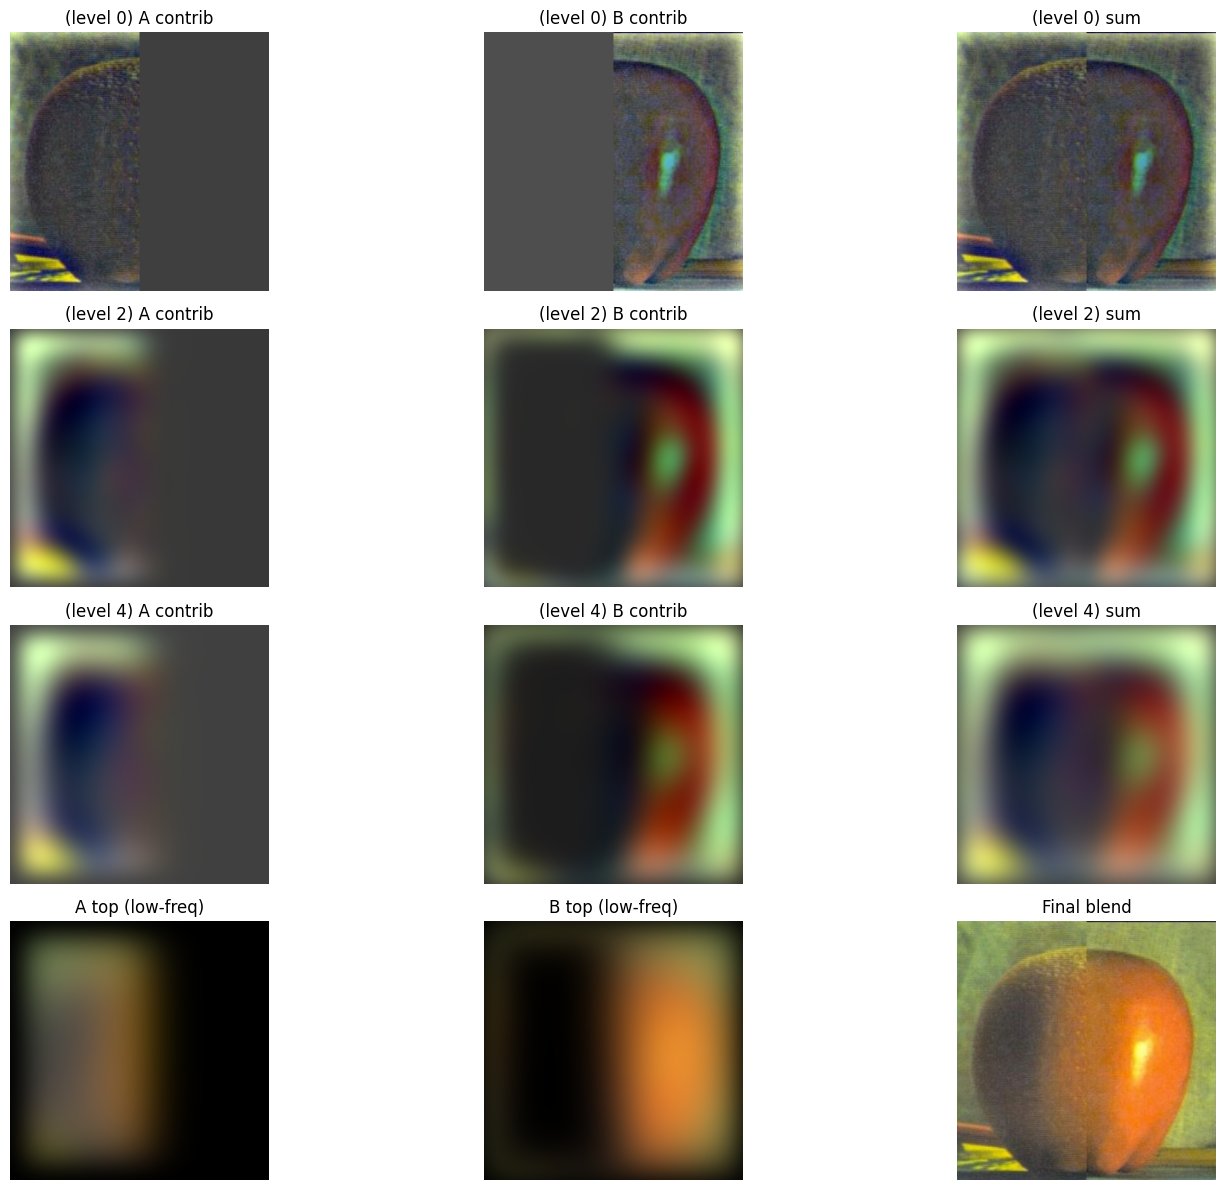

In [152]:
A_rgb = read_rgb01('pictures/orange.jpeg')
B_rgb = read_rgb01('pictures/apple.jpeg')
H, W = min(A_rgb.shape[0], B_rgb.shape[0]), min(A_rgb.shape[1], B_rgb.shape[1])
A_rgb = A_rgb[:H, :W]
B_rgb = B_rgb[:H, :W]


levels, sigma = 6, 13.0
M = make_step_mask(H, W, orientation='vertical', split=0.5)
O_rgb, (GA, GB, GM, LA, LB, LO, O_top) = multires_blend_rgb(A_rgb, B_rgb, M, levels=levels, sigma=sigma, boundary='fill')
pick = [0, 2, 4]
tiles = []
titles = []

for i in pick:
    A_contrib = GM[i][...,None]*LA[i]
    B_contrib = (1.0-GM[i])[...,None]*LB[i]
    band_sum  = A_contrib + B_contrib
    tiles += [vis01(A_contrib), vis01(B_contrib), vis01(band_sum)]
    titles += [f'(level {i}) A contrib', f'(level {i}) B contrib', f'(level {i}) sum']

A_only = GM[-1][...,None]*GA[-1]
B_only = (1.0-GM[-1])[...,None]*GB[-1]

tiles += [A_only, B_only, O_rgb]
titles += ['A top (low-freq)', 'B top (low-freq)', 'Final blend']

plt.figure(figsize=(16, 12))
for k, (img, ttl) in enumerate(zip(tiles, titles), 1):
    plt.subplot(4, 3, k)
    plt.imshow(np.clip(img,0,1))
    plt.title(ttl); plt.axis('off')
plt.tight_layout(); plt.show()


2.4 Color image blending (Orange + Apple)

In [157]:
def blend_multi(A, B, M, levels=6, sigma=2.0):
    GA = gaussian_stack(A, levels, sigma)
    GB = gaussian_stack(B, levels, sigma)
    GM = gaussian_stack(M, levels, sigma)
    LA, A_top = laplacian_stack(GA)
    LB, B_top = laplacian_stack(GB)
    LO = []
    for i in range(levels-1):
        m = GM[i][..., None] if A.ndim == 3 else GM[i]
        LO.append(m*LA[i] + (1.0-m)*LB[i])
    mtop = GM[-1][..., None] if A.ndim == 3 else GM[-1]
    O_top = mtop*A_top + (1.0-mtop)*B_top
    O = reconstruct_from_laplacian(LO, O_top)
    return np.clip(O, 0, 1)


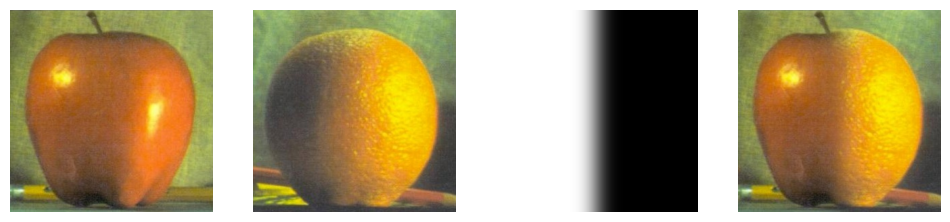

In [158]:
A = read_rgb01('pictures/apple.jpeg')
B = read_rgb01('pictures/orange.jpeg')

H, W = A.shape[:2]
B = cv2.resize(B, (W, H), interpolation=cv2.INTER_CUBIC)
M = np.zeros((H, W), np.float32); M[:, :W//2] = 1.0
M = cv2.GaussianBlur(M, (0,0), sigmaX=15)
O = blend_multi(A, B, M, levels=6, sigma=2.0)
plt.figure(figsize=(12,3))
plt.subplot(1,4,1); plt.imshow(A); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(B); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(M, cmap='gray'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(O); plt.axis('off')
plt.show()
save_rgb01('2-4_oraple.png', O)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


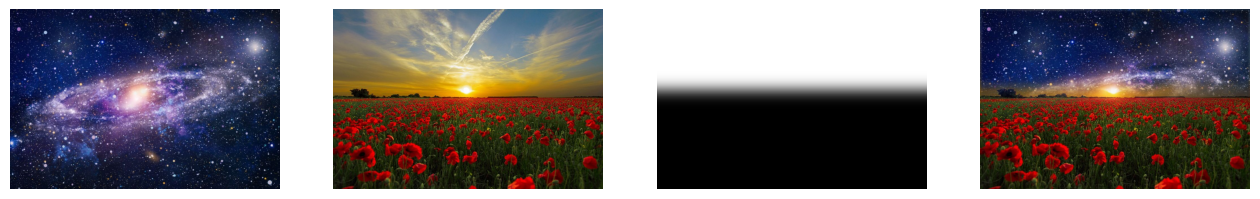

In [162]:
galaxy_path  = 'pictures/galaxy.jpg'
flowers_path = 'pictures/flowers.jpg'
A = read_rgb01(galaxy_path)
B = read_rgb01(flowers_path)
H, W = A.shape[:2]
B = cv2.resize(B, (W, H), interpolation=cv2.INTER_CUBIC)

M = np.zeros((H, W), np.float32)
cut = int(0.45 * H)
M[:cut, :] = 1.0
M = cv2.GaussianBlur(M, (0,0), sigmaX=25)
M = np.clip(M, 0, 1)

levels, sigma = 7, 2.0
O = blend_multi(A, B, M, levels=levels, sigma=sigma)

plt.figure(figsize=(16,4))
plt.subplot(1,4,1); plt.imshow(A); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(B); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(M, cmap='gray'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(O); plt.axis('off')
plt.show()
save_rgb01('2-4_galaxy_flowers.png', O)
